# Tutorial Notebook: Olist Warm-Up (Decision-Oriented Data Science)

This tutorial gives you a complete reference pipeline before you start the project workbook.

You will practice business framing, focused EDA, statistical validation, leakage-safe data splitting, baseline modeling, calibration, and threshold trade-offs.

How to use this notebook: run cells in order, read the short notes before each code block, and write one business takeaway after each section.

## 1) Business Framing

Before touching the model, define the decision clearly. In this course, this step is as important as coding.

**Business Goal**: Reduce the rate of poor customer experience linked to delivery failures.

**Actionable Decision**: Flag risky orders early so operations can trigger proactive intervention.

**Metrics to track**
- Business metric: low-review rate (1-2 stars)
- ML metric: recall, precision, ROC-AUC
- Guardrail metric: false intervention rate
- Cost metric: expected intervention cost vs prevented loss

Quick interpretation rule: a good model is only useful if it improves decisions under realistic cost and capacity constraints.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)
from sklearn.calibration import calibration_curve

# Keep results reproducible so your outputs match across reruns.
RANDOM_SEED = 42

# Use a consistent visual style for quick comparison across charts.
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

Matplotlib is building the font cache; this may take a moment.


## 2) Load Data

Expected location: ./data/ in the same folder as this notebook.

If you get a file-not-found error, confirm that all CSV files were downloaded into the data folder first.

Learning goal: understand table granularity before merging. For example, orders are at order level, while items and payments can have multiple rows per order.

In [2]:
DATA_DIR = 'data'

# Parse datetime fields now so date arithmetic works later without extra conversion.
orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv')
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv')
payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')

print('orders:', orders.shape)
print('reviews:', reviews.shape)
print('customers:', customers.shape)
print('items:', items.shape)
print('payments:', payments.shape)

# Preview a few rows to verify schema and spot obvious quality issues early.
display(orders.head(2))
display(reviews.head(2))

orders: (99441, 8)
reviews: (99224, 7)
customers: (99441, 5)
items: (112650, 7)
payments: (103886, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


## 3) Build an Order-Level Modeling Table

Target in this tutorial: is_low_review = 1 if review score is 1-2, else 0.

Why aggregate first: your prediction target is order-level, so features should be order-level too.

In this step you will:
- Aggregate item and payment rows to one row per order
- Join customer state for segment-level analysis
- Build delivery delay features and label columns

Tip: always check row counts after each merge to avoid accidental duplication.

In [4]:
# Aggregate item-level rows to one row per order.
items_agg = items.groupby('order_id', as_index=False).agg(
    n_items=('order_item_id', 'max'),
    total_freight_value=('freight_value', 'sum'),
    total_price=('price', 'sum')
)

# Aggregate payment-level rows to one row per order.
payments_agg = payments.groupby('order_id', as_index=False).agg(
    payment_value=('payment_value', 'sum'),
    n_payment_installments=('payment_installments', 'max'),
    payment_type_mode=('payment_type', lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

# Reviews can have multiple entries in raw data, so we summarize score by order.
review_agg = reviews.groupby('order_id', as_index=False).agg(
    review_score=('review_score', 'mean')
)

# Join into one modeling table.
df = (orders
      .merge(review_agg, on='order_id', how='inner')
      .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
      .merge(items_agg, on='order_id', how='left')
      .merge(payments_agg, on='order_id', how='left'))

# Positive values mean delivered after estimated date.
df['delivery_delay_days'] = (
    (df['order_delivered_customer_date'] - df['order_estimated_delivery_date'])
    .dt.total_seconds() / (24 * 3600)
)
df['delivery_delay_days'] = df['delivery_delay_days'].fillna(0)
df['is_late_delivery'] = (df['delivery_delay_days'] > 0).astype(int)
df['is_low_review'] = (df['review_score'] <= 2).astype(int)

# Keep delivered orders so delay interpretation is consistent.
df = df[df['order_status'].isin(['delivered'])].copy()

print('model table shape:', df.shape)
print('\nMissing values (top 10):')
display(df.isna().sum().sort_values(ascending=False).head(10))

df[['review_score', 'is_low_review', 'delivery_delay_days', 'is_late_delivery']].head()

model table shape: (95832, 19)

Missing values (top 10):


order_approved_at                14
order_delivered_customer_date     8
order_delivered_carrier_date      2
payment_type_mode                 1
n_payment_installments            1
payment_value                     1
order_id                          0
total_freight_value               0
is_late_delivery                  0
delivery_delay_days               0
dtype: int64

,review_score,is_low_review,delivery_delay_days,is_late_delivery
0,4.0,0,-7.107488,0
1,4.0,0,-5.355729,0
2,5.0,0,-17.245498,0
3,5.0,0,-12.980069,0
4,5.0,0,-9.238171,0


## 4) Focused EDA: Delivery Delay and Experience

Question: Are late deliveries associated with poor reviews?

Read this section like an analyst, not only as a coder:
- Compare group averages
- Compare low-review rates
- Check whether patterns are large enough to matter operationally

In [5]:
eda_summary = df.groupby('is_late_delivery').agg(
    avg_review=('review_score', 'mean'),
    low_review_rate=('is_low_review', 'mean'),
    orders=('order_id', 'count')
).reset_index()
eda_summary['low_review_rate'] = 100 * eda_summary['low_review_rate']

print('Interpretation prompt: compare low_review_rate across late-delivery groups.')
display(eda_summary)

Interpretation prompt: compare low_review_rate across late-delivery groups.


,is_late_delivery,avg_review,low_review_rate,orders
0,0,4.294311,9.187828,88171
1,1,2.566506,53.987730,7661


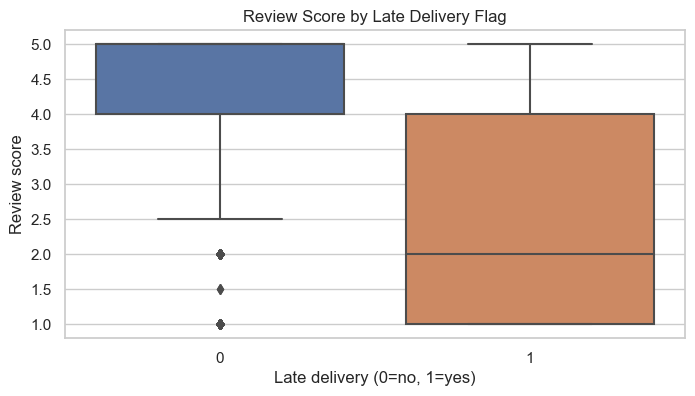

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df.sample(min(30000, len(df)), random_state=RANDOM_SEED), x='is_late_delivery', y='review_score')
plt.title('Review Score by Late Delivery Flag')
plt.xlabel('Late delivery (0=no, 1=yes)')
plt.ylabel('Review score')
plt.show()

## 5) Statistical Validation Example

Visual patterns are useful, but decisions need statistical evidence.

You will compare review-score means between on-time and late deliveries, then report:
- p-value (evidence against no difference)
- effect size (practical magnitude of difference)

Interpretation tip: very small p-values can happen with large data, so always pair p-value with effect size.

In [7]:
on_time = df.loc[df['is_late_delivery'] == 0, 'review_score'].dropna()
late = df.loc[df['is_late_delivery'] == 1, 'review_score'].dropna()

# Welch's t-test handles unequal variances between groups.
t_stat, p_value = stats.ttest_ind(on_time, late, equal_var=False)
mean_diff = on_time.mean() - late.mean()

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled_sd = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd

d = cohens_d(on_time, late)

print(f'Mean review (on-time): {on_time.mean():.3f}')
print(f'Mean review (late):    {late.mean():.3f}')
print(f'Mean difference:        {mean_diff:.3f}')
print(f'p-value:                {p_value:.3e}')
print(f"Cohen\'s d:             {d:.3f}")

if p_value < 0.05:
    print('\nResult: The difference is statistically significant at alpha=0.05.')
else:
    print('\nResult: The difference is not statistically significant at alpha=0.05.')

Mean review (on-time): 4.294
Mean review (late):    2.567
Mean difference:        1.728
p-value:                0.000e+00
Cohen's d:             1.446

Result: The difference is statistically significant at alpha=0.05.


## 6) Data Splitting Demo (Very Important)

Why split data?
- Train set: fit model parameters
- Validation set: choose threshold and compare variants
- Test set: final one-time unbiased performance estimate

Leakage warning: do not use test data during feature design or threshold tuning.

What to check after splitting:
- Similar target rate across train, validation, and test
- No accidental overlap by order_id
- Reproducibility with a fixed random seed

In [8]:
feature_cols = [
    'delivery_delay_days',
    'is_late_delivery',
    'n_items',
    'total_freight_value',
    'total_price',
    'payment_value',
    'n_payment_installments',
    'payment_type_mode',
    'customer_state'
]

model_df = df[feature_cols + ['is_low_review']].copy()
X = model_df[feature_cols]
y = model_df['is_low_review']

# Step 1: reserve a final test set that stays untouched until the very end.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# Step 2: split remaining data into train and validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_val
)

print('Train size:', len(X_train))
print('Val size:  ', len(X_val))
print('Test size: ', len(X_test))

print('Low-review rate (overall):', y.mean().round(4))
print('Low-review rate (train):  ', y_train.mean().round(4))
print('Low-review rate (val):    ', y_val.mean().round(4))
print('Low-review rate (test):   ', y_test.mean().round(4))

# Optional safety check: verify no index overlap after split.
overlap = set(X_train.index).intersection(set(X_val.index)).intersection(set(X_test.index))
print('Shared indices across all splits:', len(overlap))

Train size: 57498
Val size:   19167
Test size:  19167
Low-review rate (overall): 0.1277
Low-review rate (train):   0.1277
Low-review rate (val):     0.1277
Low-review rate (test):    0.1277
Shared indices across all splits: 0


## 7) Baseline Model (Logistic Regression)

Use a simple baseline first. The goal here is to build a reliable decision aid, not to maximize complexity.

Why this model works for a tutorial:
- Fast to train
- Easy to explain
- Produces probabilities needed for threshold and calibration analysis

In [9]:
numeric_features = [
    'delivery_delay_days',
    'is_late_delivery',
    'n_items',
    'total_freight_value',
    'total_price',
    'payment_value',
    'n_payment_installments'
]
categorical_features = ['payment_type_mode', 'customer_state']

# Build preprocessing so missing values and categories are handled consistently.
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

clf = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

clf.fit(X_train, y_train)
val_proba = clf.predict_proba(X_val)[:, 1]

print('Validation ROC-AUC:', round(roc_auc_score(y_val, val_proba), 4))
print('Validation PR-AUC: ', round(average_precision_score(y_val, val_proba), 4))

# Interpretation note: PR-AUC is especially informative when the positive class is less frequent.

Validation ROC-AUC: 0.7342
Validation PR-AUC:  0.3886


## 8) Calibration Check

Calibration answers this question: if the model predicts 0.80 risk, does about 80% actually occur?

For operational decisions, well-calibrated probabilities are often more useful than high ranking metrics alone.

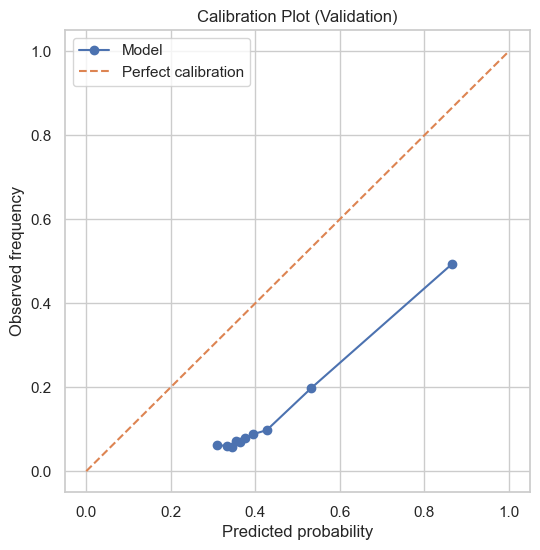

In [10]:
frac_pos, mean_pred = calibration_curve(y_val, val_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(mean_pred, frac_pos, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Plot (Validation)')
plt.legend()
plt.show()

## 9) Threshold and Cost Trade-Off (Validation Set)

You are not selecting a threshold by intuition. You are selecting it by decision economics.

Example assumptions:
- Proactive intervention cost = $2 per flagged order
- Missed truly risky order cost = $50

Tune threshold on validation only, then lock it before touching test data.

Top threshold candidates by estimated total cost:


,threshold,precision,recall,flagged_orders,missed_risky_orders,estimated_total_cost
0,0.2,0.127773,1.000000,19159,0,38318.0
1,0.1,0.127740,1.000000,19164,0,38328.0
2,0.3,0.129128,0.991830,18803,20,38606.0
3,0.4,0.247648,0.634395,6271,895,57292.0
4,0.5,0.386096,0.508170,3222,1204,66644.0
5,0.6,0.470042,0.413399,2153,1436,76106.0
6,0.7,0.497879,0.383578,1886,1509,79222.0
7,0.8,0.524735,0.363971,1698,1557,81246.0
8,0.9,0.646226,0.111928,424,2174,109548.0


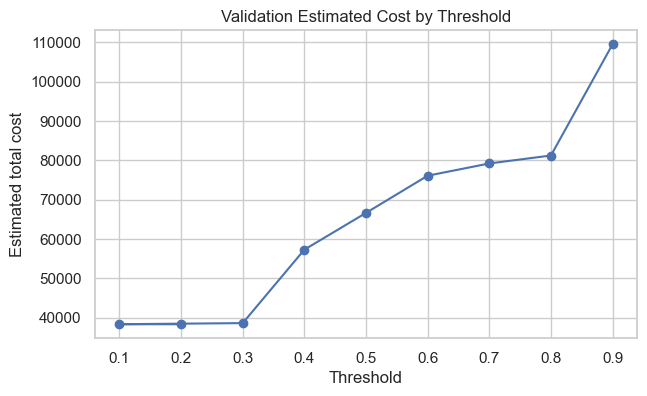

In [11]:
INTERVENTION_COST = 2.0
MISS_COST = 50.0

def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    intervention_spend = (tp + fp) * INTERVENTION_COST
    missed_loss = fn * MISS_COST
    total_cost = intervention_spend + missed_loss
    return {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'flagged_orders': tp + fp,
        'missed_risky_orders': fn,
        'estimated_total_cost': total_cost
    }

threshold_grid = np.arange(0.1, 0.91, 0.1)
results = pd.DataFrame([evaluate_threshold(y_val.values, val_proba, t) for t in threshold_grid])
results = results.sort_values('estimated_total_cost').reset_index(drop=True)

print('Top threshold candidates by estimated total cost:')
display(results.head(10))

plt.figure(figsize=(7, 4))
plt.plot(results['threshold'], results['estimated_total_cost'], marker='o')
plt.title('Validation Estimated Cost by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Estimated total cost')
plt.show()

## 10) Final Test Evaluation (Single Use)

Choose the threshold from validation results, then evaluate once on test data.

Why one-time use matters: if you keep tuning after seeing test results, your estimate becomes optimistic and less trustworthy.

In [12]:
best_threshold = float(results.sort_values('estimated_total_cost').iloc[0]['threshold'])
test_proba = clf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print('Chosen threshold from validation:', best_threshold)
print('Test ROC-AUC:', round(roc_auc_score(y_test, test_proba), 4))
print('Test PR-AUC: ', round(average_precision_score(y_test, test_proba), 4))
print('\nClassification report on test set:')
print(classification_report(y_test, test_pred, digits=3))

cm = confusion_matrix(y_test, test_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
print('\nConfusion matrix (test set):')
display(cm_df)

Chosen threshold from validation: 0.2
Test ROC-AUC: 0.7281
Test PR-AUC:  0.3811

Classification report on test set:
              precision    recall  f1-score   support

           0      0.833     0.000     0.001     16720
           1      0.128     1.000     0.226      2447

    accuracy                          0.128     19167
   macro avg      0.480     0.500     0.113     19167
weighted avg      0.743     0.128     0.029     19167


Confusion matrix (test set):


,Pred 0,Pred 1
Actual 0,5,16715
Actual 1,1,2446


## 11) Mini Recommendation Example

Use this format when writing your final recommendations:
1. Action: Trigger proactive support for high-risk orders above the chosen threshold.
2. Evidence: Late deliveries are associated with poorer review outcomes, and the model has decision-useful discrimination.
3. Expected impact: Reduce missed risky orders while keeping intervention volume manageable.
4. Risk: False interventions add cost and operations workload.
5. Confidence: Moderate, and should be improved through pilot monitoring.

## 12) Quick Practice Tasks (Optional but Recommended)

1. Change intervention cost from 2 to 5 and rerun threshold selection. What changes?
2. Compare thresholds by precision and recall, not just cost. Which threshold would Finance prefer? Which would Customer Experience prefer?
3. Replace the low-review target (1-2 stars) with a stricter target (1 star only). How does model difficulty change?